In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [37]:
#  Выбор компаний и загрузка данных с NYSE
companies = ['KYOCY', 'XRX']  # Kyocera и Xerox ("заклятые" конкуренты на рынке печатного оборудования)
start_date = '2017-01-01'
end_date = '2025-04-30'

data = {}
for company in companies:
    print(f"Загрузка данных для {company}...")
    df_temp = yf.download(company, start=start_date, end=end_date, progress=False, auto_adjust=False)
    if df_temp.empty:
        print(f"Ошибка: Данные для {company} не загрузились. Проверьте тикер или подключение.")
    else:
        print(f"Успешно загружено {len(df_temp)} записей для {company}")
        print("Столбцы в df_temp:", df_temp.columns)
        data[company] = df_temp['Adj Close'][company]

# Создание DataFrame с выравниванием индексов
if not data:
    raise ValueError("Нет данных для создания DataFrame. Проверьте загрузку.")
df = pd.DataFrame(data)
df.columns = ['Kyocera', 'Xerox']
df = df.dropna()
df.to_csv('stock_prices_kyocera_xerox.csv')
print("Первые строки датасета:")
print(df.head())

Загрузка данных для KYOCY...
Успешно загружено 2092 записей для KYOCY
Столбцы в df_temp: MultiIndex([('Adj Close', 'KYOCY'),
            (    'Close', 'KYOCY'),
            (     'High', 'KYOCY'),
            (      'Low', 'KYOCY'),
            (     'Open', 'KYOCY'),
            (   'Volume', 'KYOCY')],
           names=['Price', 'Ticker'])
Загрузка данных для XRX...
Успешно загружено 2092 записей для XRX
Столбцы в df_temp: MultiIndex([('Adj Close', 'XRX'),
            (    'Close', 'XRX'),
            (     'High', 'XRX'),
            (      'Low', 'XRX'),
            (     'Open', 'XRX'),
            (   'Volume', 'XRX')],
           names=['Price', 'Ticker'])
Первые строки датасета:
            Kyocera      Xerox
Date                          
2017-01-03  12.4600  17.971489
2017-01-04  12.8000  18.649664
2017-01-05  12.6950  18.571404
2017-01-06  12.6825  18.284494
2017-01-09  12.6775  18.180159


In [39]:
#  Основные статистики
print("\nОсновные статистики для Kyocera:")
print(df['Kyocera'].describe())
print("\nОсновные статистики для Xerox:")
print(df['Xerox'].describe())


Основные статистики для Kyocera:
count    2092.000000
mean       14.141767
std         1.690963
min         9.400000
25%        12.991875
50%        14.181250
75%        15.338125
max        17.930000
Name: Kyocera, dtype: float64

Основные статистики для Xerox:
count    2092.000000
mean       16.352435
std         4.671562
min         3.640000
25%        12.930359
50%        16.378126
75%        19.249536
max        28.249359
Name: Xerox, dtype: float64


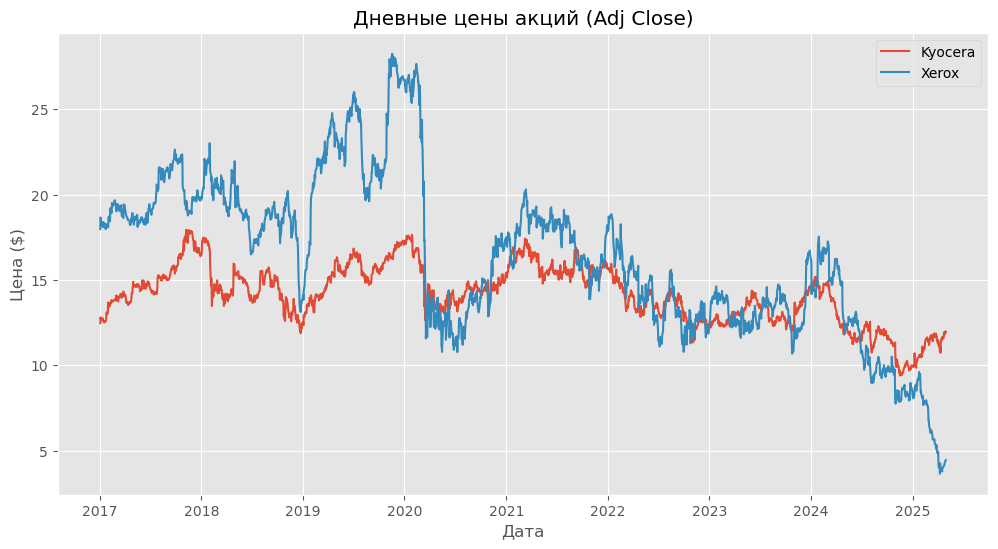

In [41]:
# Визуализация исходных рядов
plt.figure(figsize=(12, 6))
plt.plot(df['Kyocera'], label='Kyocera')
plt.plot(df['Xerox'], label='Xerox')
plt.title('Дневные цены акций (Adj Close)')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.legend()
plt.show()

Ковид сильно подкосил Ксерокс, Киосера пострадала  заметно меньше.

In [50]:
#  Проверка стационарности
def adf_test(series, title=''):
    print(f'Тест Дики-Фуллера для {title}:')
    result = adfuller(series.dropna())
    print(f'ADF Статистика: {result[0]}')
    print(f'p-значение: {result[1]}')
    print('Критические значения:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    if result[1] < 0.05:
        print("Ряд стационарен (p < 0.05)\n")
    else:
        print("Ряд нестационарен (p >= 0.05)\n")

adf_test(df['Kyocera'], 'Kyocera')
adf_test(df['Xerox'], 'Xerox')

Тест Дики-Фуллера для Kyocera:
ADF Статистика: -2.571517339304064
p-значение: 0.09902809396783191
Критические значения:
	1%: -3.433502335224827
	5%: -2.8629325603267475
	10%: -2.567511334824936
Ряд нестационарен (p >= 0.05)

Тест Дики-Фуллера для Xerox:
ADF Статистика: -1.6142683295695615
p-значение: 0.4757354426573531
Критические значения:
	1%: -3.4334932438197754
	5%: -2.862928546266631
	10%: -2.5675091975687785
Ряд нестационарен (p >= 0.05)



Проведён тест Дики-Фуллера для проверки стационарности рядов Kyocera и Xerox. На основе p-значения определено отсутствие стационарности. Необходимо привести ряды к стационарному виду

Тест Дики-Фуллера для Kyocera (разности):
ADF Статистика: -11.960435401198712
p-значение: 4.114380358790616e-22
Критические значения:
	1%: -3.433502335224827
	5%: -2.8629325603267475
	10%: -2.567511334824936
Ряд стационарен (p < 0.05)

Тест Дики-Фуллера для Xerox (разности):
ADF Статистика: -14.848816587809218
p-значение: 1.79013751615973e-27
Критические значения:
	1%: -3.4334932438197754
	5%: -2.862928546266631
	10%: -2.5675091975687785
Ряд стационарен (p < 0.05)



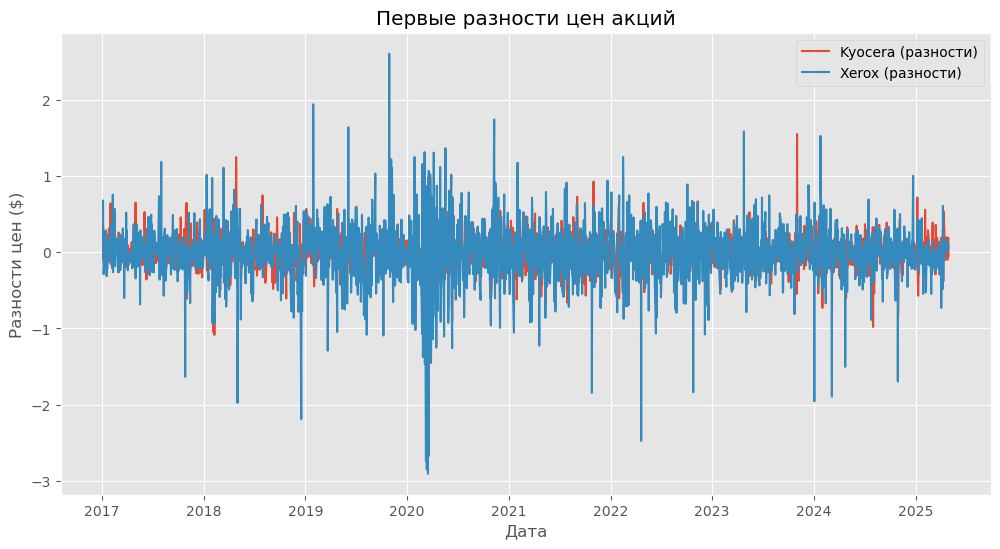

In [59]:
#  Преобразуем в стационарный ряд (стационарность легко определяется визуально: если ряд "болтается" около нуля - значит ряд стационарен)
# Применяем дифференцирование для приведения рядов к стационарному виду. Используем тест Дики-Фуллера для определения стационарности.
df_diff = df.diff().dropna()
adf_test(df_diff['Kyocera'], 'Kyocera (разности)')
adf_test(df_diff['Xerox'], 'Xerox (разности)')

plt.figure(figsize=(12, 6))
plt.plot(df_diff['Kyocera'], label='Kyocera (разности)')
plt.plot(df_diff['Xerox'], label='Xerox (разности)')
plt.title('Первые разности цен акций')
plt.xlabel('Дата')
plt.ylabel('Разности цен ($)')
plt.legend()
plt.show()

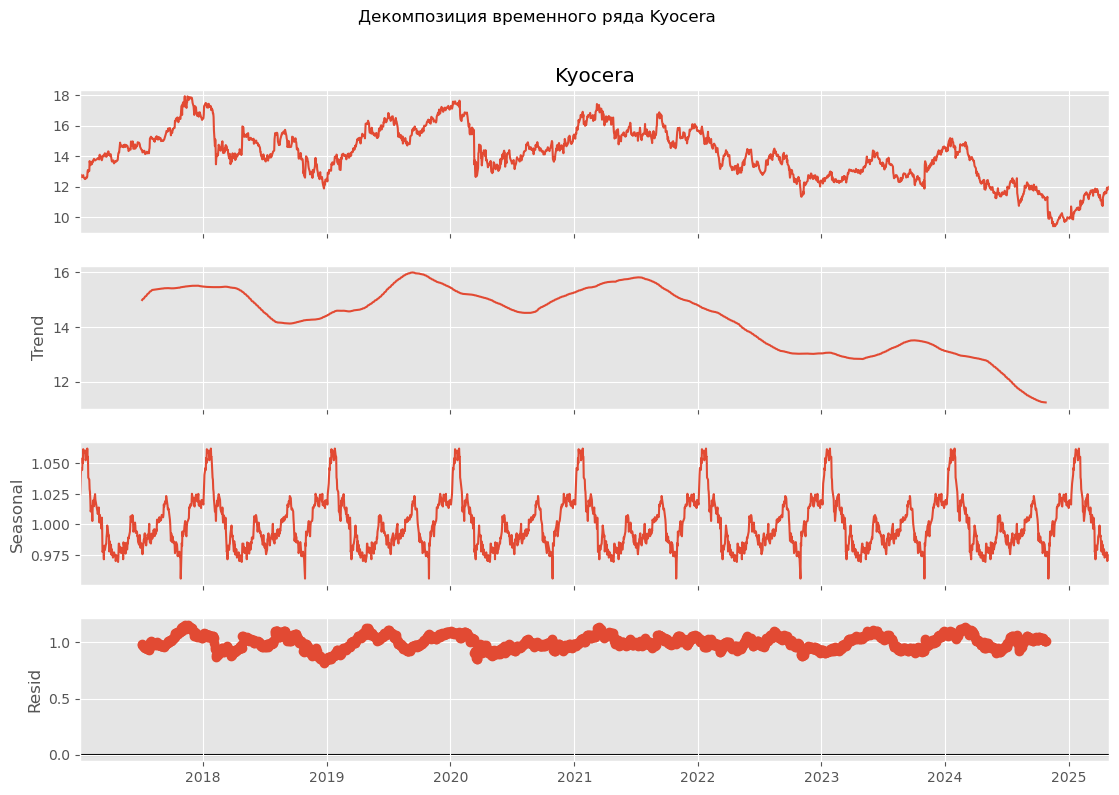

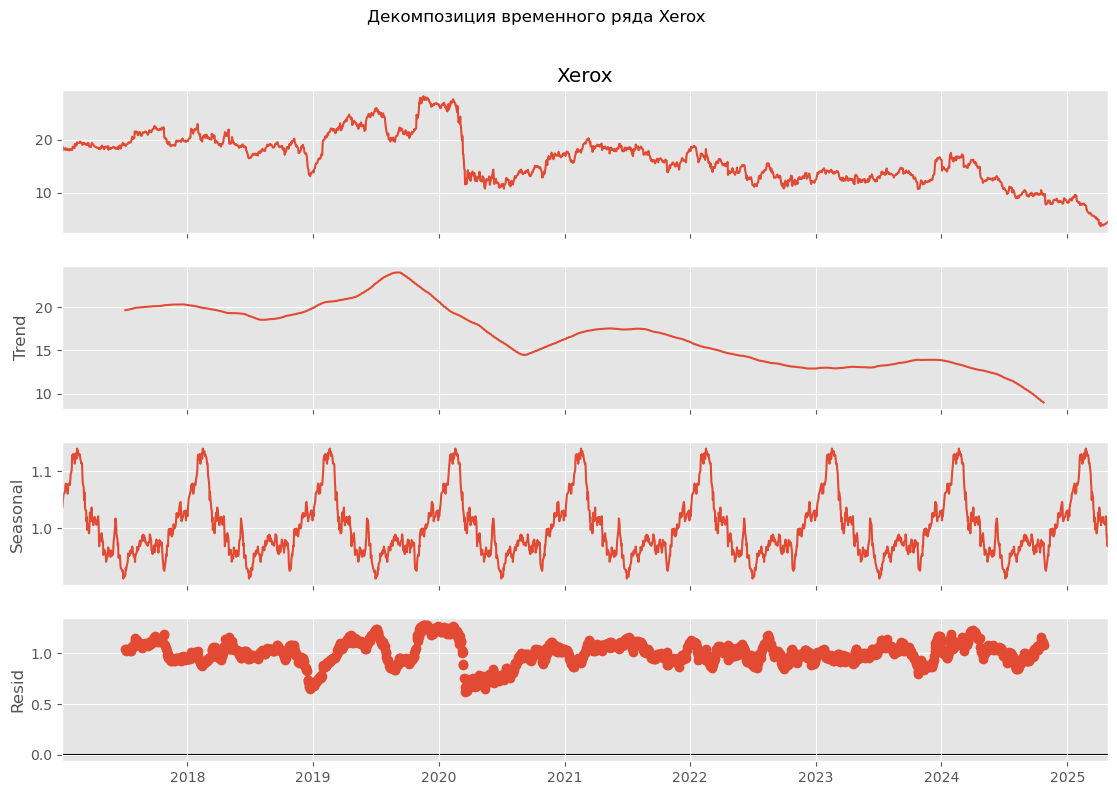

In [65]:
#  Декомпозиция временного ряда (выделение тренда. сезонности и остатков)
# 252 - количество торговых дней на бирже в году
decomposition_kyocera = seasonal_decompose(df['Kyocera'], model='multiplicative', period=252)  
fig = decomposition_kyocera.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Декомпозиция временного ряда Kyocera', y=1.02)
plt.show()

decomposition_xerox = seasonal_decompose(df['Xerox'], model='multiplicative', period=252)
fig = decomposition_xerox.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Декомпозиция временного ряда Xerox', y=1.02)
plt.show()

Интерпретация результатов для Kyocera:
1) На верхнем графике показаны цены акций Kyocera с 2017 по 2025 год. Ряд демонстрирует значительные колебания: рост с 2017 до начала 2020, резкое падение в 2020 (вероятно, из-за пандемии), восстановление до 2022, а затем постепенный спад с пиками и провалами до 2025 года.
Цены акций имеют выраженные периоды роста и падения, что указывает на наличие тренда и волатильности.

2) Тренд показывает долгосрочное движение цен. С 2017 года тренд растёт до 2019, затем слегка снижается в 2020, снова растёт до 2022, после чего начинается устойчивый спад до 2025 года.
Акции Kyocera имели общий восходящий тренд до 2022 года, но после этого началось снижение, что может быть связано с макроэкономическими факторами.

3) Сезонный компонент колеблется в диапазоне примерно от 0.9 до 1.15. Это указывает на регулярные повторяющиеся колебания с периодом 252 дня. Колебания выглядят довольно стабильными на протяжении всего периода.
В ценах акций Kyocera присутствует слабая годовая сезонность.

4)Остатки колеблются в диапазоне от 0.5 до 1.5, с более сильными отклонениями в 2017–2020 годах и меньшими после 2022 года. Остатки представляют собой случайные или необъяснённые изменения после учёта тренда и сезонности.
Остатки показывают, что в начале периода (2017–2020) в данных было больше случайных колебаний, возможно, из-за высокой волатильности рынка. После 2022 года остатки становятся более стабильными, что может указывать на уменьшение непредсказуемых факторов.




Интерпретация результатов для Xerox:
1) На верхнем графике показаны цены акций Xerox с 2017 по 2025 год. Цены начинаются около 18 долларов, достигают пика около 22 долларов в начале 2020 года, затем резко падают до 10 долларов в 2020 году (COVID-19). После этого ряд колеблется в диапазоне 10–15 долларов с постепенным снижением к 2025 году.
Цены акций Xerox демонстрируют значительные колебания с резким падением в 2020 году, после чего не восстанавливаются до прежнего уровня, показывая общий нисходящий тренд.

2) Тренд показывает долгосрочное движение цен. С 2017 года тренд слегка растёт до начала 2020 года (с 18 до 20 долларов), затем резко падает до 12 долларов в 2020 году. После этого тренд стабилизируется на уровне 12–14 долларов до 2023 года, а затем постепенно снижается до 10 долларов к 2025 году.
Акции Xerox имеют выраженный нисходящий тренд после 2020 года. Падение в 2020 году, вероятно, связано с пандемией, и компания не смогла восстановить прежний уровень цен, что может быть связано с проблемами в бизнесе или отрасли.

3) Практически идентичные результаты с Kyocera,  присутствует слабая годовая сезонность.

4) Остатки колеблются в диапазоне от 0.5 до 1.5 и показывают, что в 2017–2020 годах в данных было больше случайных колебаний, вероятно, из-за высокой волатильности рынка. После 2021 года остатки становятся более стабильными, что может указывать на снижение непредсказуемых факторов.

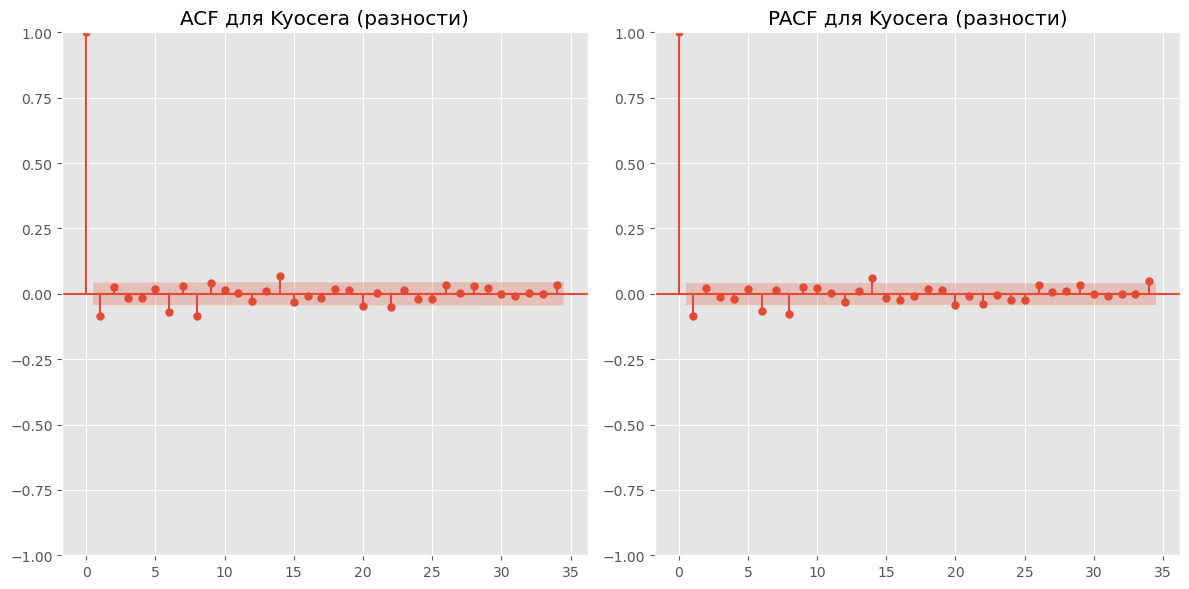

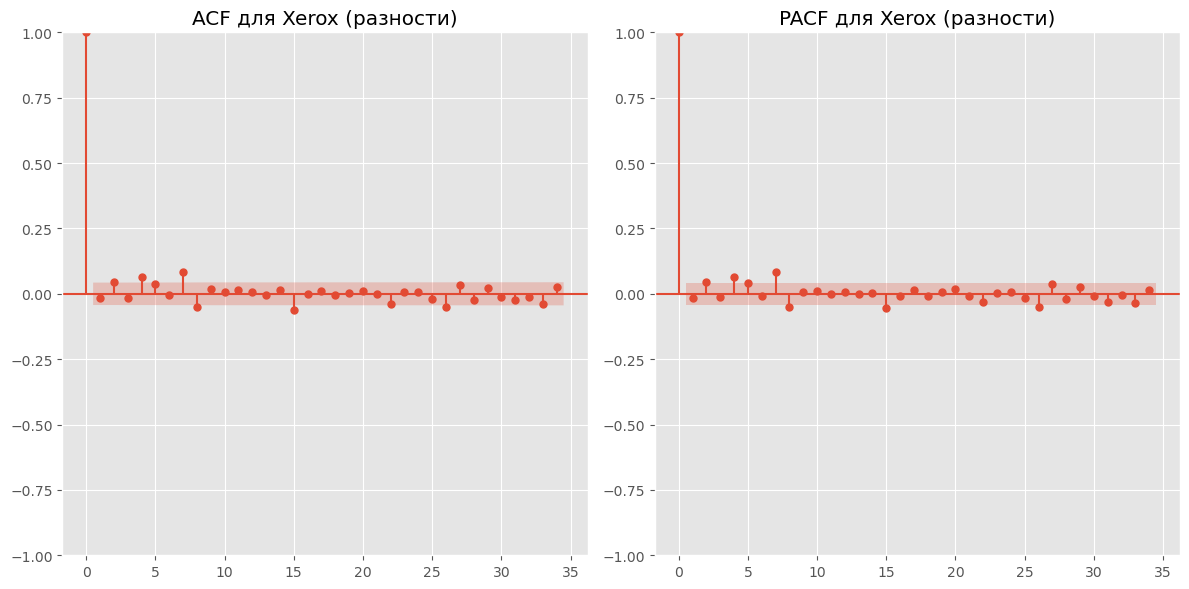

In [35]:
# ACF и PACF для анализа автокорреляции
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df_diff['Kyocera'], ax=plt.gca(), title='ACF для Kyocera (разности)')
plt.subplot(122)
plot_pacf(df_diff['Kyocera'], ax=plt.gca(), title='PACF для Kyocera (разности)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df_diff['Xerox'], ax=plt.gca(), title='ACF для Xerox (разности)')
plt.subplot(122)
plot_pacf(df_diff['Xerox'], ax=plt.gca(), title='PACF для Xerox (разности)')
plt.tight_layout()
plt.show()

Сходство рядов: И для Xerox, и для Kyocera разности рядов близки к белому шуму, что подтверждает их стационарность после дифференцирования. 

Различия: У Kyocera есть небольшие пики на лагах 5, 10, 15 в PACF, что может указывать на остаточную сезонность, в то время как у Xerox таких пиков нет.